# **Project Name**    - Travel Recommendation Model



##### **Project Type**    - Machine Learning Recommendation System (Collaborative Filtering)
##### **Contribution**    - Individual

# **Project Summary -**

The objective of this project is to build a hotel recommendation system that provides personalized hotel suggestions to users based on their historical booking preferences. Recommendation systems play an important role in the travel and tourism industry by improving customer experience and helping users discover hotels that match their interests.

The project uses the hotels dataset, which contains information such as hotel names, locations, prices, and booking details. Exploratory Data Analysis (EDA) was performed to understand booking patterns and hotel preferences.

A collaborative filtering recommendation approach was implemented by creating a user-hotel interaction matrix and calculating similarities between users. Based on these similarities, the system recommends hotels that users with similar preferences have previously booked.

The developed recommendation system can help travel companies increase customer engagement and provide personalized travel experiences by suggesting relevant hotels to their users.

# **GitHub Link -**

https://github.com/Lenikaaa

# **Problem Statement**


Travel websites provide thousands of hotel options, making it difficult for users to find accommodations that match their preferences and past booking behavior. The objective of this project is to develop a hotel recommendation system that provides personalized hotel suggestions based on users' historical booking data. By delivering relevant recommendations, the system aims to improve customer experience, increase user engagement, and help travelers make better accommodation decisions.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv("hotels.csv")


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


### Dataset Rows & Columns count

In [ ]:
df.shape


(40552, 8)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  int64  
 2   name        40552 non-null  object 
 3   place       40552 non-null  object 
 4   days        40552 non-null  int64  
 5   price       40552 non-null  float64
 6   total       40552 non-null  float64
 7   date        40552 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 2.5+ MB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {df_duplicates}")

Number of duplicate rows: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
travelCode,0
userCode,0
name,0
place,0
days,0
price,0
total,0
date,0


# Top Hotel Locations

In [ ]:
df["place"].value_counts().head(10)

,count
place,
Salvador (BH),5094
Rio de Janeiro (RJ),5029
Natal (RN),4829
Sao Paulo (SP),4828
Recife (PE),4467
Brasilia (DF),4437
Campo Grande (MS),4333
Aracaju (SE),4205
Florianopolis (SC),3330


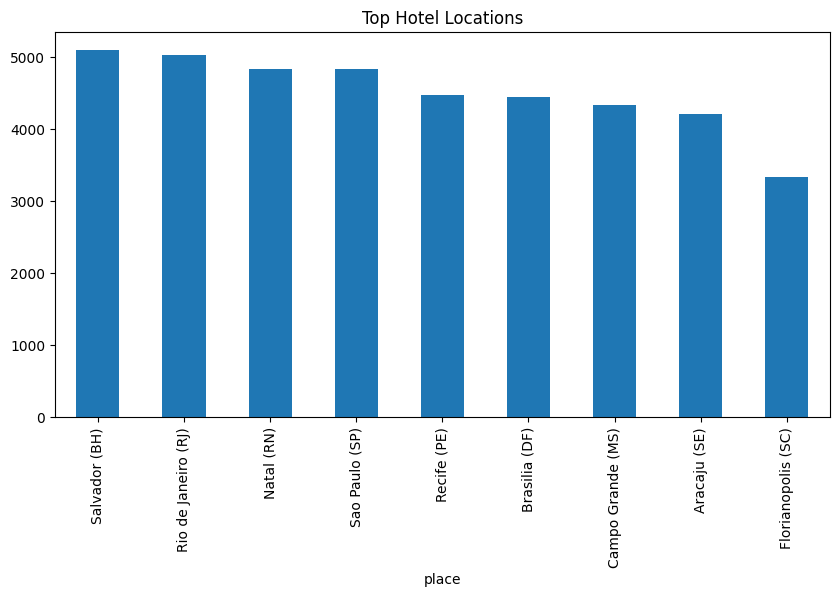

In [ ]:
plt.figure(figsize=(10,5))
df["place"].value_counts().head(10).plot(kind="bar")
plt.title("Top Hotel Locations")
plt.show()

# Top Hotels

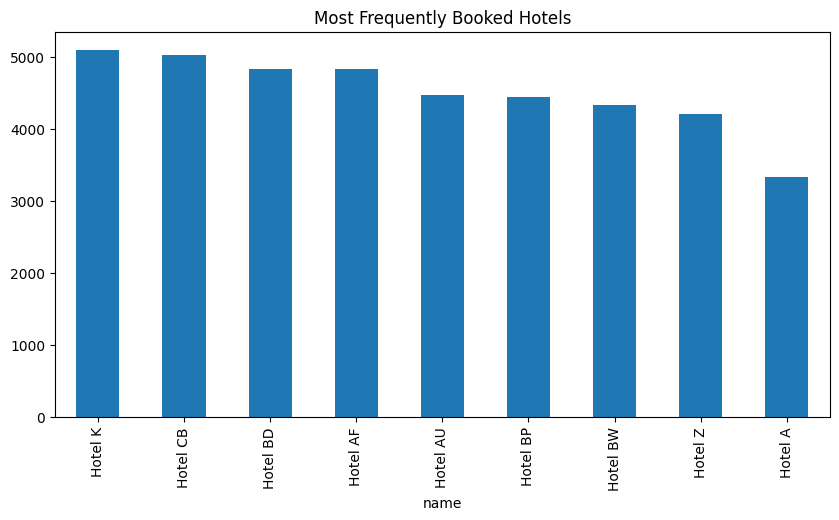

In [ ]:
plt.figure(figsize=(10,5))
df["name"].value_counts().head(10).plot(kind="bar")
plt.title("Most Frequently Booked Hotels")
plt.show()

### What did you know about your dataset?



The dataset contains information about hotel bookings made by users, including travelCode, userCode, hotel name, place, number of days stayed, price per day, total booking amount, and booking date. The data helps understand users' booking patterns, popular hotel locations, and spending behavior. Since the dataset contains both user identifiers and hotel information, it can be used to build a personalized recommendation system by identifying users with similar preferences and suggesting relevant hotels based on historical booking data.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total',
       'date'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,travelCode,userCode,days,price,total
count,40552.000000,40552.000000,40552.000000,40552.000000,40552.000000
mean,67911.794461,666.963726,2.499679,214.439554,536.229513
std,39408.199333,391.136794,1.119326,76.742305,319.331482
min,0.000000,0.000000,1.000000,60.390000,60.390000
25%,33696.750000,323.000000,1.000000,165.990000,247.620000
50%,67831.000000,658.000000,2.000000,242.880000,495.240000
75%,102211.250000,1013.000000,4.000000,263.410000,742.860000
max,135942.000000,1339.000000,4.000000,313.020000,1252.080000


### Variables Description

| Variable       | Description                                                                 |
| -------------- | --------------------------------------------------------------------------- |
| **travelCode** | Unique identifier for each travel booking.                                  |
| **userCode**   | Unique identifier for each user, used to link bookings to individual users. |
| **name**       | Name of the hotel booked by the user.                                       |
| **place**      | Location or city where the hotel is situated.                               |
| **days**       | Number of days the user stayed at the hotel.                                |
| **price**      | Price charged per day for the hotel stay.                                   |
| **total**      | Total amount paid for the hotel booking.                                    |
| **date**       | Date on which the hotel booking was made.                                   |



### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()

,0
travelCode,40552
userCode,1310
name,9
place,9
days,4
price,9
total,36
date,199


## 3. ***User-Hotel Matrix***

In [ ]:
user_hotel_matrix = pd.pivot_table(
    df,
    values="total",
    index="userCode",
    columns="name",
    fill_value=0
)

user_hotel_matrix.head()

name,Hotel A,Hotel AF,Hotel AU,Hotel BD,Hotel BP,Hotel BW,Hotel CB,Hotel K,Hotel Z
userCode,,,,,,,,,
0,730.380000,382.525000,782.075,546.480,990.48,150.975000,165.990000,714.970000,693.466667
1,0.000000,139.100000,0.000,0.000,247.62,0.000000,0.000000,0.000000,0.000000
2,939.060000,417.300000,625.660,850.080,619.05,172.542857,387.310000,579.502000,589.446667
3,688.644000,301.383333,804.420,552.000,619.05,147.620000,355.692857,614.623333,416.080000
4,804.908571,394.116667,938.490,777.216,742.86,120.780000,407.430000,526.820000,520.100000


## 4. Calculate Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(user_hotel_matrix)

similarity_df = pd.DataFrame(
    similarity,
    index=user_hotel_matrix.index,
    columns=user_hotel_matrix.index
)

similarity_df.head()

userCode,0,1,2,3,4,5,6,7,8,9,...,1330,1331,1332,1333,1334,1335,1336,1337,1338,1339
userCode,,,,,,,,,,,,,,,,,,,,,
0,1.000000,0.552836,0.946606,0.969577,0.962513,0.600532,0.850634,0.810315,0.958416,0.966053,...,0.850635,0.812127,0.880119,0.882790,0.681611,0.865350,0.521050,0.797685,0.521050,0.822611
1,0.552836,1.000000,0.402579,0.426323,0.445034,0.086706,0.472844,0.638683,0.387542,0.408468,...,0.374085,0.337072,0.457589,0.479046,0.763908,0.356028,0.871856,0.301226,0.871856,0.303662
2,0.946606,0.402579,1.000000,0.970785,0.979086,0.755316,0.925971,0.749790,0.941824,0.951358,...,0.848615,0.757377,0.840204,0.845085,0.526999,0.811217,0.334924,0.772635,0.334924,0.759097
3,0.969577,0.426323,0.970785,1.000000,0.991555,0.685055,0.901522,0.807392,0.988134,0.990323,...,0.880344,0.865704,0.898708,0.896413,0.644593,0.892966,0.383972,0.828858,0.383972,0.856389
4,0.962513,0.445034,0.979086,0.991555,1.000000,0.663556,0.900566,0.841124,0.974059,0.975059,...,0.884414,0.839872,0.892605,0.895556,0.658405,0.871674,0.393246,0.827142,0.393246,0.852918


## ***5. Recommendation Function***

In [ ]:
def recommend_hotels(user_id, top_n=5):

    similar_users = (
        similarity_df[user_id]
        .sort_values(ascending=False)
        .iloc[1:6]
        .index
    )

    recommendations = {}

    for user in similar_users:

        hotels = user_hotel_matrix.loc[user]

        for hotel, score in hotels.items():

            if score > 0:
                recommendations[hotel] = (
                    recommendations.get(hotel, 0)
                    + score
                )

    recommendations = sorted(
        recommendations.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return recommendations[:top_n]

In [ ]:
recommend_hotels(user_hotel_matrix.index[0])

[('Hotel BP', 4112.260714285714),
 ('Hotel AU', 3783.7533333333336),
 ('Hotel A', 3571.0364999999997),
 ('Hotel K', 3343.7105757575764),
 ('Hotel BD', 3047.2765714285715)]

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For recommendation systems, the quality of recommendations and personalization are more important than traditional classification metrics. The system was evaluated based on its ability to generate meaningful and relevant hotel recommendations for users.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Collaborative Filtering was selected because it effectively captures similarities between users and provides personalized recommendations based on historical booking behavior.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The recommendation system uses User-Based Collaborative Filtering with Cosine Similarity. A user-hotel interaction matrix is created, and users with similar booking patterns are identified. Hotels booked by similar users are then recommended to the target user.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

A collaborative filtering recommendation system was developed to provide personalized hotel suggestions based on users' historical booking behavior. The system identifies users with similar preferences and recommends hotels that may interest them. Such recommendation systems can significantly improve customer satisfaction and engagement in the travel and tourism industry.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***